# 03 — Spatial Risk Analysis: Station Risk Scoring

We join CitiBike station locations with NYPD accident data to produce a per-station **risk score** — the foundation of dynamic premium pricing.

**Method:**
1. Build a 250m buffer around each CitiBike station
2. Count NYPD accidents (all / bicycle-involved) inside each buffer
3. Compute severity score (injuries per accident) and combine it with number of accidents to a risk score.
4. Visualize on an interactive map

**Why 250m?** At ~15 km/h cycling speed, 250m is ~1 minute of riding — the immediate accident exposure zone around a station departure or arrival.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')

import zipfile
import polars as pl
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from pathlib import Path

from src.features.risk_features import (
    stations_to_geodataframe,
    accidents_to_geodataframe,
    compute_station_risk_scores,
    compute_destination_risk,
)
from src.visualization.maps import make_risk_map

PROC_DIR = Path('../data/processed')
RAW_DIR  = Path('../data/raw')
FIG_DIR  = Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Preprocessed Station Table

Stations are deduplicated by name in `src/data/preprocess.py` (run `make preprocess`).
Multiple station IDs mapping to the same physical location are merged.

In [2]:
stations = pl.read_parquet(PROC_DIR / 'stations.parquet')
print(f'Unique stations: {len(stations):,}')
stations.head(5)

Unique stations: 2,236


name,station_id,latitude,longitude
str,str,f64,f64
"""49 Ave & 21 St""","""6128.04""",40.74252,-73.948852
"""E 10 St & Ave A""","""5659.05""",40.727408,-73.98142
"""Southern Blvd & E 180 St""","""8325.08""",40.84605,-73.88426
"""W 107 St & Columbus Ave""","""7619.05""",40.799757,-73.962113
"""Huron St & Franklin St""","""5869.04""",40.73266,-73.95826


## 2. Load NYPD Accidents

In [3]:
nypd = pl.read_parquet(PROC_DIR / 'nypd_2025.parquet')
print(f'NYPD 2025 records: {len(nypd):,}')

accidents_gdf = accidents_to_geodataframe(nypd)
print(f'After coordinate cleaning: {len(accidents_gdf):,}')

NYPD 2025 records: 82,699
After coordinate cleaning: 82,699


## 3. Spatial Join: Accidents within 250m of Each Station

In [4]:
stations_gdf = stations_to_geodataframe(stations)

station_risk = compute_station_risk_scores(
    stations_gdf,
    accidents_gdf,
    buffer_m=250,
)

# Percentile-based risk boundaries (P25 / P75)
p25 = station_risk['risk_score'].quantile(0.25)
p75 = station_risk['risk_score'].quantile(0.75)
print(f'Risk thresholds: Low < {p25:.3f} | Med {p25:.3f}–{p75:.3f} | High > {p75:.3f}')

print(f'\nStations with risk scores: {len(station_risk):,}')
print()
print('Risk score distribution:')
print(station_risk['risk_score'].describe().round(3))

high_risk = (station_risk['risk_score'] > p75).sum()
print(f'\nHigh-risk stations (score > {p75:.3f}): {high_risk} ({high_risk/len(station_risk):.1%} of all stations)')

Risk thresholds: Low < 0.117 | Med 0.117–0.294 | High > 0.294

Stations with risk scores: 2,236

Risk score distribution:
count    2236.000
mean        0.222
std         0.148
min         0.000
25%         0.117
50%         0.190
75%         0.294
max         1.000
Name: risk_score, dtype: float64

High-risk stations (score > 0.294): 551 (24.6% of all stations)


In [5]:
## 3b. Load slim trip data for destination risk (start + end station IDs only)

TRIP_COLS = ['start_station_id', 'end_station_id']
trip_files = sorted(RAW_DIR.glob('2025??-citibike-tripdata.zip'))

trip_dfs = []
for f in trip_files:
    with zipfile.ZipFile(f) as zf:
        with zf.open(zf.namelist()[0]) as csv_file:
            trip_dfs.append(
                pl.read_csv(csv_file, columns=TRIP_COLS,
                            schema_overrides={c: pl.String for c in TRIP_COLS})
            )

trips_slim = pl.concat(trip_dfs).drop_nulls()
print(f'Trips loaded: {len(trips_slim):,} rows (start + end station IDs only)')

Trips loaded: 9,531,049 rows (start + end station IDs only)


In [6]:
## 3c. Blend local risk with destination risk (70/30)

LOCAL_WEIGHT = 0.70

station_risk = compute_destination_risk(trips_slim, station_risk, local_weight=LOCAL_WEIGHT)

# Recompute thresholds on the blended score
p25 = station_risk['risk_score'].quantile(0.25)
p75 = station_risk['risk_score'].quantile(0.75)
print(f'Updated risk thresholds: Low < {p25:.3f} | Med {p25:.3f}–{p75:.3f} | High > {p75:.3f}')

lift = station_risk['risk_score'] - station_risk['local_risk_score']
print(f'\nDestination risk lift (blended − local):')
print(f'  Mean:  {lift.mean():+.4f}')
print(f'  Max:   {lift.max():+.4f}')
print(f'  Min:   {lift.min():+.4f}')
print(f'  Stations lifted  > 0.05: {(lift > 0.05).sum()}')
print(f'  Stations reduced > 0.05: {(lift < -0.05).sum()}')

Updated risk thresholds: Low < 0.144 | Med 0.144–0.286 | High > 0.286

Destination risk lift (blended − local):
  Mean:  +0.0068
  Max:   +0.1764
  Min:   -0.2027
  Stations lifted  > 0.05: 156
  Stations reduced > 0.05: 176


In [7]:
station_risk

,name,station_id,latitude,longitude,geometry,station_idx,accident_count,bike_accident_count,cyclist_injuries,total_injuries,bike_severity,severity_score,bike_accident_rate,local_risk_score,destination_risk_score,risk_score
0,49 Ave & 21 St,6128.04,40.742520,-73.948852,POINT (-73.94885 40.74252),0,12.0,0.0,0.0,6.0,0.000000,0.500000,0.000000,0.073620,0.150388,0.096650
1,E 10 St & Ave A,5659.05,40.727408,-73.981420,POINT (-73.98142 40.72741),1,21.0,8.0,6.0,13.0,0.750000,0.619048,0.380952,0.300613,0.328020,0.308835
2,Southern Blvd & E 180 St,8325.08,40.846050,-73.884260,POINT (-73.88426 40.84605),2,23.0,5.0,6.0,20.0,1.200000,0.869565,0.217391,0.276074,0.226493,0.261199
3,W 107 St & Columbus Ave,7619.05,40.799757,-73.962113,POINT (-73.96211 40.79976),3,16.0,4.0,3.0,7.0,0.750000,0.437500,0.250000,0.184049,0.271036,0.210145
4,Huron St & Franklin St,5869.04,40.732660,-73.958260,POINT (-73.95826 40.73266),4,16.0,7.0,5.0,7.0,0.714286,0.437500,0.437500,0.245399,0.229023,0.240486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,Lenox Ave & W 133 St,7790.04,40.812960,-73.941878,POINT (-73.94188 40.81296),2231,36.0,8.0,8.0,16.0,1.000000,0.444444,0.222222,0.417178,0.354428,0.398353
2232,Lafayette Ave & Hunts Point Ave,7883.06,40.816567,-73.888161,POINT (-73.88816 40.81657),2232,21.0,1.0,1.0,4.0,1.000000,0.190476,0.047619,0.153374,0.254482,0.183707
2233,Greene Ave & Grandview Ave,5106.04,40.709697,-73.907856,POINT (-73.90786 40.7097),2233,10.0,1.0,1.0,7.0,1.000000,0.700000,0.100000,0.085890,0.221713,0.126636
2234,Leonard St & Maujer St,5148.03,40.710369,-73.947060,POINT (-73.94706 40.71037),2234,32.0,12.0,11.0,24.0,0.916667,0.750000,0.375000,0.478528,0.255763,0.411698


## 4. Top High-Risk Stations

In [8]:
top10 = station_risk.nlargest(10, 'risk_score')[[
    'name', 'bike_accident_count', 'cyclist_injuries',
    'bike_severity', 'accident_count', 'risk_score'
]].reset_index(drop=True)

top10.columns = ['Station', 'Bike Accidents', 'Cyclist Injuries', 'Bike Severity', 'All Accidents', 'Risk Score']
print('Top 10 Highest-Risk CitiBike Stations (2025)')
print(top10.to_string(index=False))

Top 10 Highest-Risk CitiBike Stations (2025)
                        Station  Bike Accidents  Cyclist Injuries  Bike Severity  All Accidents  Risk Score
St Nicholas Ave & Manhattan Ave            22.0              15.0       0.681818           89.0    0.797347
                W 42 St & 8 Ave            14.0               9.0       0.642857           95.0    0.721211
     St Nicholas Ave & W 126 St            18.0              12.0       0.666667           89.0    0.720764
                W 36 St & 7 Ave            18.0              13.0       0.722222           79.0    0.717810
         Norfolk St & Broome St            21.0              16.0       0.761905           71.0    0.712331
        Wallabout St & Kent Ave             6.0               3.0       0.500000          129.0    0.710758
                E 1 St & Bowery            22.0              16.0       0.727273           63.0    0.696212
                W 45 St & 8 Ave            16.0               8.0       0.500000           

## 5. Risk Score Distribution by Category

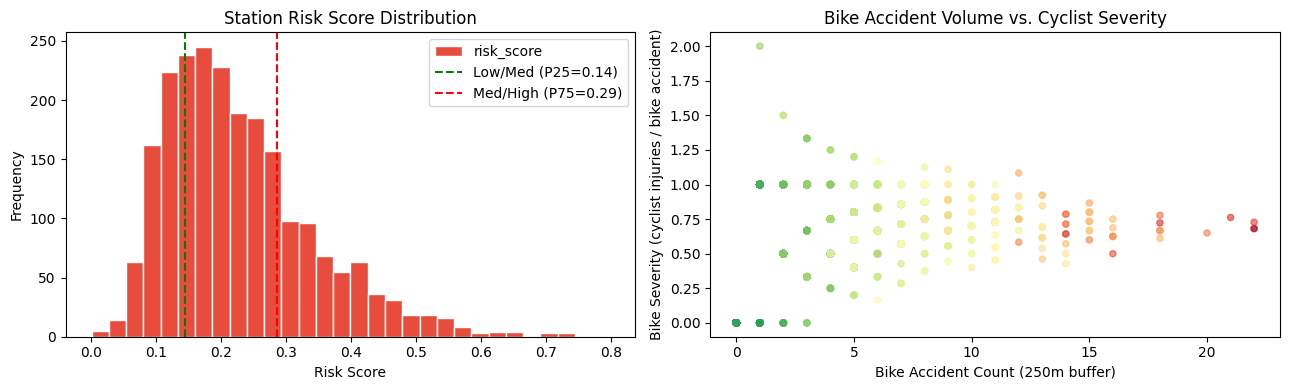

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
station_risk['risk_score'].plot.hist(bins=30, ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].axvline(p25, color='green', linestyle='--', label=f'Low/Med (P25={p25:.2f})')
axes[0].axvline(p75, color='red', linestyle='--', label=f'Med/High (P75={p75:.2f})')
axes[0].set_title('Station Risk Score Distribution')
axes[0].set_xlabel('Risk Score')
axes[0].legend()

# Scatter: bike accident count vs bike severity
sc = axes[1].scatter(
    station_risk['bike_accident_count'],
    station_risk['bike_severity'],
    c=station_risk['risk_score'],
    cmap='RdYlGn_r',
    alpha=0.6, s=20,
)
axes[1].set_xlabel('Bike Accident Count (250m buffer)')
axes[1].set_ylabel('Bike Severity (cyclist injuries / bike accident)')
axes[1].set_title('Bike Accident Volume vs. Cyclist Severity')

plt.tight_layout()
plt.savefig(FIG_DIR / '03_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
station_risk

,name,station_id,latitude,longitude,geometry,station_idx,accident_count,bike_accident_count,cyclist_injuries,total_injuries,bike_severity,severity_score,bike_accident_rate,local_risk_score,destination_risk_score,risk_score
0,49 Ave & 21 St,6128.04,40.742520,-73.948852,POINT (-73.94885 40.74252),0,12.0,0.0,0.0,6.0,0.000000,0.500000,0.000000,0.073620,0.150388,0.096650
1,E 10 St & Ave A,5659.05,40.727408,-73.981420,POINT (-73.98142 40.72741),1,21.0,8.0,6.0,13.0,0.750000,0.619048,0.380952,0.300613,0.328020,0.308835
2,Southern Blvd & E 180 St,8325.08,40.846050,-73.884260,POINT (-73.88426 40.84605),2,23.0,5.0,6.0,20.0,1.200000,0.869565,0.217391,0.276074,0.226493,0.261199
3,W 107 St & Columbus Ave,7619.05,40.799757,-73.962113,POINT (-73.96211 40.79976),3,16.0,4.0,3.0,7.0,0.750000,0.437500,0.250000,0.184049,0.271036,0.210145
4,Huron St & Franklin St,5869.04,40.732660,-73.958260,POINT (-73.95826 40.73266),4,16.0,7.0,5.0,7.0,0.714286,0.437500,0.437500,0.245399,0.229023,0.240486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,Lenox Ave & W 133 St,7790.04,40.812960,-73.941878,POINT (-73.94188 40.81296),2231,36.0,8.0,8.0,16.0,1.000000,0.444444,0.222222,0.417178,0.354428,0.398353
2232,Lafayette Ave & Hunts Point Ave,7883.06,40.816567,-73.888161,POINT (-73.88816 40.81657),2232,21.0,1.0,1.0,4.0,1.000000,0.190476,0.047619,0.153374,0.254482,0.183707
2233,Greene Ave & Grandview Ave,5106.04,40.709697,-73.907856,POINT (-73.90786 40.7097),2233,10.0,1.0,1.0,7.0,1.000000,0.700000,0.100000,0.085890,0.221713,0.126636
2234,Leonard St & Maujer St,5148.03,40.710369,-73.947060,POINT (-73.94706 40.71037),2234,32.0,12.0,11.0,24.0,0.916667,0.750000,0.375000,0.478528,0.255763,0.411698


## 6. Interactive Risk Map 

Station markers are sized and coloured by risk score. The NYPD accident heatmap is shown as an underlying layer. Boundaries are based on percentiles (P25 / P75).

- **Green:** Low risk (bottom 25%)
- **Orange:** Medium risk (25th–75th percentile)
- **Red:** High risk (top 25%)

In [11]:
nypd_bike = pl.read_parquet(PROC_DIR / 'nypd_bike_2025.parquet')
accidents_bike_gdf = accidents_to_geodataframe(nypd_bike)

risk_map = make_risk_map(
    station_risk,
    accidents_gdf=accidents_bike_gdf,
    center=(40.730, -73.990),
    zoom=12,
    low_threshold=p25,
    high_threshold=p75,
)

risk_map.save(str(FIG_DIR / '03_station_risk_map.html'))
print('Map saved to outputs/figures/03_station_risk_map.html')
risk_map

Map saved to outputs/figures/03_station_risk_map.html


## 7. Save Station Risk Scores

Notebook 04 loads this to attach risk features to each trip.

In [12]:
output_cols = [
    'station_id', 'name', 'latitude', 'longitude',
    'accident_count', 'bike_accident_count', 'cyclist_injuries',
    'total_injuries', 'bike_severity', 'severity_score',
    'bike_accident_rate',
    'local_risk_score',
    'destination_risk_score',
    'risk_score',
]
pl.from_pandas(station_risk[output_cols]).write_parquet(
    PROC_DIR / 'station_risk_scores.parquet'
)
print(f'Saved {len(station_risk):,} station risk scores to data/processed/station_risk_scores.parquet')

Saved 2,236 station risk scores to data/processed/station_risk_scores.parquet


## 8. Insurance Implication

The spatial analysis reveals **geographic risk concentration**: a minority of stations account for the majority of accident exposure. 

- **Premium uplift** is justified for departures/arrivals at high-risk stations
- **Adverse selection risk** is manageable: casual riders (our target) tend to use Manhattan stations which cluster in the mid-risk tier
- **Station-level risk scores** serve as the primary feature in notebook 04's pricing model

**Next:** `04_risk_model.ipynb` — apply the formula-based risk model and implement the premium calculator.